# 03 — Transit Search (BLS + TLS)
Runs both **Box Least Squares (BLS)** and **Transit Least Squares (TLS)** on all cleaned light curves.
TLS uses a physical transit shape — more sensitive than BLS for real planet signals.

## 1. Imports

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.timeseries import BoxLeastSquares
import astropy.units as u
from tqdm import tqdm
import os, glob, warnings
warnings.filterwarnings('ignore')

# Install TLS if needed
try:
    from transitleastsquares import transitleastsquares, cleaned_array
    TLS_OK = True
    print('TLS ✅')
except ImportError:
    os.system('pip install transitleastsquares')
    try:
        from transitleastsquares import transitleastsquares, cleaned_array
        TLS_OK = True
        print('TLS installed ✅')
    except:
        TLS_OK = False
        print('TLS not available — using BLS only')

print('Imports OK!')

TLS ✅
Imports OK!


## 2. Configuration

In [10]:
# Corrupted stars — exclude from all analysis
EXCLUDE_TICS = ['261203535']

In [11]:
PROCESSED_DIR = '../data/processed/'
RESULTS_DIR   = '../outputs/'
PLOTS_DIR     = '../outputs/plots/'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,   exist_ok=True)

# Search parameters
MIN_PERIOD    = 1.0
MAX_PERIOD    = 13.0
MIN_DURATION  = 0.01
MAX_DURATION  = 0.3
SNR_THRESHOLD = 5.0

csv_files = glob.glob(os.path.join(PROCESSED_DIR, 'TIC_*.csv'))
print(f'Found {len(csv_files)} processed light curves')

Found 20 processed light curves


## 3. BLS Function (unchanged)

In [12]:
def run_bls(time, flux, min_period=1.0, max_period=13.0,
            min_duration=0.01, max_duration=0.3):
    mask = np.isfinite(flux)
    time, flux = time[mask], flux[mask]
    if len(time) < 100:
        return None
    max_dur_safe = min(max_duration, min_period * 0.8)
    durations    = np.linspace(min_duration, max_dur_safe, 20) * u.day
    bls          = BoxLeastSquares(time * u.day, flux)
    periodogram  = bls.autopower(
        durations,
        minimum_period  = min_period * u.day,
        maximum_period  = max_period * u.day,
        method='fast'
    )
    best_idx  = np.argmax(periodogram.power)
    stats     = bls.compute_stats(
        periodogram.period[best_idx],
        periodogram.duration[best_idx],
        periodogram.transit_time[best_idx]
    )
    depth     = float(stats['depth'][0])
    depth_err = float(stats['depth'][1])
    snr       = depth / depth_err if depth_err > 0 else 0.0
    return {
        'best_period'   : float(periodogram.period[best_idx].value),
        'best_duration' : float(periodogram.duration[best_idx].value),
        'best_depth'    : depth,
        'snr'           : snr,
        'bls_power'     : float(np.max(periodogram.power)),
        'transit_time'  : float(periodogram.transit_time[best_idx].value),
        'periodogram'   : periodogram
    }

print('BLS ready!')

BLS ready!


## 4. TLS Function (NEW)

In [ ]:
def run_tls(time, flux, min_period=1.0, max_period=13.0):
    """
    Run Transit Least Squares (TLS) on a light curve.
    NOTE: TLS result.depth = REMAINING FLUX (1=no transit, 0=total eclipse).
          We convert to fractional drop to match BLS convention.
    """
    if not TLS_OK:
        return None

    time_c, flux_c = cleaned_array(time, flux)
    if len(time_c) < 100:
        return None

    try:
        model  = transitleastsquares(time_c, flux_c)
        result = model.power(
            minimum_period   = min_period,
            maximum_period   = max_period,
            show_progress_bar= False
        )

        # TLS depth = remaining flux fraction (1 - transit_depth_fraction)
        # Convert to fractional drop so it matches BLS convention
        
        depth_frac_drop = float(result.depth)             # 0.003
        rp_rs_corrected  = float(np.sqrt(max(depth_frac_drop, 0.0)))  # sqrt(0.003) ≈ 0.055

        return {
            'best_period'      : float(result.period),
            'best_duration'    : float(result.duration),
            'best_depth'       : depth_frac_drop,        # fractional drop (0.003 not 0.997)
            'sde'              : float(result.SDE),
            'fap'              : float(result.FAP) if np.isfinite(result.FAP) else 1.0,
            'snr'              : float(result.snr),
            'transit_time'     : float(result.T0),
            'transit_times'    : list(result.transit_times),
            'rp_rs'            : rp_rs_corrected,        # correct Rp/R* ratio
            'odd_even_mismatch': float(result.odd_even_mismatch),
            'result_obj'       : result
        }
    except Exception as e:
        print(f'TLS error: {e}')
        return None

print('TLS ready!')

TLS ready!


## 5. Run Both BLS and TLS on All Light Curves

In [14]:
all_results = []

for csv_path in tqdm(csv_files, desc='BLS + TLS Search'):
    tic_id = os.path.basename(csv_path).replace('TIC_','').replace('.csv','')
    if tic_id in EXCLUDE_TICS:
        print(f'Skipping corrupted star: TIC {tic_id}')
        continue

    try:
        df   = pd.read_csv(csv_path)
        time = df['time'].values
        flux = df['flux'].values
        mask = np.isfinite(time) & np.isfinite(flux)
        time, flux = time[mask], flux[mask]

        if len(time) < 100:
            continue

        # ── Run BLS ──────────────────────────────────────
        bls_res = run_bls(time, flux, MIN_PERIOD, MAX_PERIOD,
                          MIN_DURATION, MAX_DURATION)

        # ── Run TLS ──────────────────────────────────────
        tls_res = run_tls(time, flux, MIN_PERIOD, MAX_PERIOD)

        # ── Combine results ───────────────────────────────
        row = {'tic_id': tic_id}

        if bls_res:
            row.update({
                'period_days'    : bls_res['best_period'],
                'duration_days'  : bls_res['best_duration'],
                'depth_ppm'      : bls_res['best_depth'] * 1e6,
                'snr'            : bls_res['snr'],
                'bls_power'      : bls_res['bls_power'],
                'transit_time'   : bls_res['transit_time'],
            })

        if tls_res:
            row.update({
                'tls_period'     : tls_res['best_period'],
                'tls_duration'   : tls_res['best_duration'],
                'tls_depth_ppm'  : tls_res['best_depth'] * 1e6,
                'tls_snr'        : tls_res['snr'],
                'tls_sde'        : tls_res['sde'],
                'tls_fap'        : tls_res['fap'],
                'tls_rp_rs'      : tls_res['rp_rs'],
                'tls_odd_even'   : tls_res['odd_even_mismatch'],
                'tls_transit_time': tls_res['transit_time'],
            })

            # Use TLS values as primary if available
            row['period_days']  = tls_res['best_period']
            row['duration_days']= tls_res['best_duration']
            row['depth_ppm']    = tls_res['best_depth'] * 1e6
            row['snr']          = tls_res['snr']
            row['transit_time'] = tls_res['transit_time']

        # Period agreement between BLS and TLS
        if bls_res and tls_res:
            p_agree = abs(bls_res['best_period'] - tls_res['best_period'])
            p_agree_pct = p_agree / bls_res['best_period'] * 100
            row['bls_tls_period_agree_pct'] = p_agree_pct
            # If both agree on period → more confident detection
            row['both_agree'] = p_agree_pct < 5.0

        all_results.append(row)

        # Print summary
        bls_snr = bls_res['snr'] if bls_res else 0
        tls_snr = tls_res['snr'] if tls_res else 0
        tls_fap = tls_res['fap'] if tls_res else 1.0
        print(f'TIC {tic_id}  BLS_SNR={bls_snr:.1f}  '
              f'TLS_SNR={tls_snr:.1f}  TLS_FAP={tls_fap:.4f}')

    except Exception as e:
        print(f'TIC {tic_id} FAILED: {e}')

results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(RESULTS_DIR, 'bls_all_results.csv'), index=False)
print(f'\nDone! {len(results_df)} stars processed')
print(results_df[['tic_id','period_days','depth_ppm','snr',
                  'tls_snr','tls_fap']].to_string())

BLS + TLS Search:   0%|          | 0/20 [00:00<?, ?it/s]

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 17139 data points, 2327 periods from 0.601 to 12.888 days
Using all 12 CPU threads
Searching for best T0 for period 5.53310 days


BLS + TLS Search:   5%|▌         | 1/20 [01:38<31:09, 98.37s/it]

TIC 14091633  BLS_SNR=0.0  TLS_SNR=31.1  TLS_FAP=0.0001
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 36 durations
Searching 14578 data points, 1902 periods from 0.601 to 10.886 days
Using all 12 CPU threads
Searching for best T0 for period 1.35251 days


BLS + TLS Search:  10%|█         | 2/20 [03:05<27:28, 91.58s/it]

...

TIC 52555068  BLS_SNR=0.1  TLS_SNR=15.8  TLS_FAP=0.0043
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 1128 data points, 2351 periods from 0.602 to 13.001 days
Using all 12 CPU threads
Searching for best T0 for period 2.83685 days


BLS + TLS Search:  95%|█████████▌| 19/20 [14:18<00:33, 33.49s/it]

TIC 62867537  BLS_SNR=0.1  TLS_SNR=15.7  TLS_FAP=0.0001
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 17200 data points, 2313 periods from 0.601 to 12.82 days
Using all 12 CPU threads
Searching for best T0 for period 1.17763 days


BLS + TLS Search: 100%|██████████| 20/20 [15:04<00:00, 45.23s/it]

TIC 92880568  BLS_SNR=0.1  TLS_SNR=32.1  TLS_FAP=0.0001

Done! 20 stars processed
       tic_id  period_days      depth_ppm        snr    tls_snr   tls_fap
0    14091633     5.533104  996198.617798  31.125499  31.125499  0.000080
1   143271144     1.352505  988463.992404   7.948647   7.948647  0.000080
2   144276942     1.534554  997776.191991   9.556993   9.556993  0.000080
3   144327080     4.419863  998794.629095   4.580289   4.580289  1.000000
4   151681127    10.168175  999348.013239   4.680603   4.680603  0.000080
5   153077621     2.959163  999481.027453   4.551118   4.551118  1.000000
6   207425203     1.224596  998818.653808   7.928081   7.928081  0.000080
7    20897611     3.134811  992518.024133  21.528414  21.528414  0.000080
8   241196395     2.093715  998149.111967  24.643744  24.643744  0.000080
9   248391319     0.799249  997946.252976  10.957419  10.957419  0.000080
10  270515566    10.049862  997079.534892   6.016411   6.016411  0.000080
11  308883808     1.165255  99

In [15]:
# Also run BLS+TLS on labeled training data
LABELED_PROCESSED_DIR = '../data/labeled/processed/'
labeled_csv_files = glob.glob(os.path.join(LABELED_PROCESSED_DIR, 'TIC_*.csv'))
print(f'\nRunning BLS+TLS on {len(labeled_csv_files)} labeled files...')

labeled_results = []
for csv_path in tqdm(labeled_csv_files, desc='Labeled BLS+TLS'):
    tic_id = os.path.basename(csv_path).replace('TIC_','').replace('.csv','')
    try:
        df   = pd.read_csv(csv_path)
        time = df['time'].values
        flux = df['flux'].values
        mask = np.isfinite(time) & np.isfinite(flux)
        time, flux = time[mask], flux[mask]
        if len(time) < 100:
            continue
        bls_res = run_bls(time, flux, MIN_PERIOD, MAX_PERIOD, MIN_DURATION, MAX_DURATION)
        tls_res = run_tls(time, flux, MIN_PERIOD, MAX_PERIOD)
        row = {'tic_id': tic_id}
        if bls_res:
            row.update({'period_days': bls_res['best_period'],
                        'duration_days': bls_res['best_duration'],
                        'depth_ppm': bls_res['best_depth'] * 1e6,
                        'snr': bls_res['snr'],
                        'bls_power': bls_res['bls_power'],
                        'transit_time': bls_res['transit_time']})
        if tls_res:
            row.update({'tls_period': tls_res['best_period'],
                        'tls_duration': tls_res['best_duration'],
                        'tls_depth_ppm': tls_res['best_depth'] * 1e6,
                        'tls_snr': tls_res['snr'],
                        'tls_sde': tls_res['sde'],
                        'tls_fap': tls_res['fap'],
                        'tls_rp_rs': tls_res['rp_rs'],
                        'tls_odd_even': tls_res['odd_even_mismatch'],
                        'tls_transit_time': tls_res['transit_time']})
            row.update({'period_days': tls_res['best_period'],
                        'duration_days': tls_res['best_duration'],
                        'depth_ppm': tls_res['best_depth'] * 1e6,
                        'snr': tls_res['snr']})
        labeled_results.append(row)
    except Exception as e:
        print(f'TIC {tic_id} FAILED: {e}')

labeled_results_df = pd.DataFrame(labeled_results)
labeled_results_df.to_csv(os.path.join(RESULTS_DIR, 'bls_labeled_results.csv'), index=False)
print(f'Labeled BLS+TLS done: {len(labeled_results_df)} stars')



Running BLS+TLS on 104 labeled files...


Labeled BLS+TLS:   0%|          | 0/104 [00:00<?, ?it/s]

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 18163 data points, 2536 periods from 0.601 to 13.859 days
Using all 12 CPU threads
Searching for best T0 for period 3.68734 days


Labeled BLS+TLS:   1%|          | 1/104 [00:48<1:23:24, 48.59s/it]

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 37 durations
Searching 16253 data points, 2227 periods from 0.601 to 12.419 days
Using all 12 CPU threads
Searching for best T0 for period 8.50014 days


...

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 1153 data points, 2497 periods from 0.601 to 13.677 days
Using all 12 CPU threads
Searching for best T0 for period 13.40961 days


Labeled BLS+TLS:  99%|█████████▉| 103/104 [12:05:09<01:02, 62.80s/it]

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 16537 data points, 2385 periods from 0.602 to 13.159 days
Using all 12 CPU threads
Searching for best T0 for period 10.44926 days


Labeled BLS+TLS: 100%|██████████| 104/104 [12:06:38<00:00, 419.22s/it]

Labeled BLS+TLS done: 104 stars


## 6. Flag Candidates Using Both BLS and TLS

In [16]:
# Candidate if EITHER BLS or TLS flags it
candidates_df = results_df[
    (results_df['snr'] >= SNR_THRESHOLD) |
    (results_df.get('tls_snr', pd.Series(0, index=results_df.index)) >= SNR_THRESHOLD) |
    (results_df.get('tls_fap', pd.Series(1, index=results_df.index)) < 0.05)
].copy()

candidates_df = candidates_df.sort_values('snr', ascending=False).reset_index(drop=True)
candidates_df.to_csv(os.path.join(RESULTS_DIR, 'bls_candidates.csv'), index=False)

print(f'Total stars          : {len(results_df)}')
print(f'Candidates flagged   : {len(candidates_df)}')
print()
print('Top candidates:')
cols = ['tic_id','period_days','depth_ppm','snr','tls_snr','tls_fap']
cols = [c for c in cols if c in candidates_df.columns]
print(candidates_df[cols].head(10).to_string())

Total stars          : 20
Candidates flagged   : 18

Top candidates:
      tic_id  period_days      depth_ppm        snr    tls_snr   tls_fap
0   51912829     0.835142  997880.593897  69.895819  69.895819  0.000080
1  468997317     3.760680  996546.231435  47.010654  47.010654  0.000080
2   92880568     1.177626  997206.276743  32.137981  32.137981  0.000080
3   14091633     5.533104  996198.617798  31.125499  31.125499  0.000080
4  241196395     2.093715  998149.111967  24.643744  24.643744  0.000080
5   20897611     3.134811  992518.024133  21.528414  21.528414  0.000080
6  308883808     1.165255  998354.690729  16.454064  16.454064  0.000080
7   52555068     2.805705  994282.212288  15.829426  15.829426  0.004322
8   62867537     2.836851  985273.749916  15.660848  15.660848  0.000080
9  408094424     2.491557  997811.441699  15.408023  15.408023  0.000080


## 7. Plot BLS vs TLS Comparison for Top Star

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 18244 data points, 2554 periods from 0.601 to 13.94 days
Using all 12 CPU threads
Searching for best T0 for period 0.83514 days


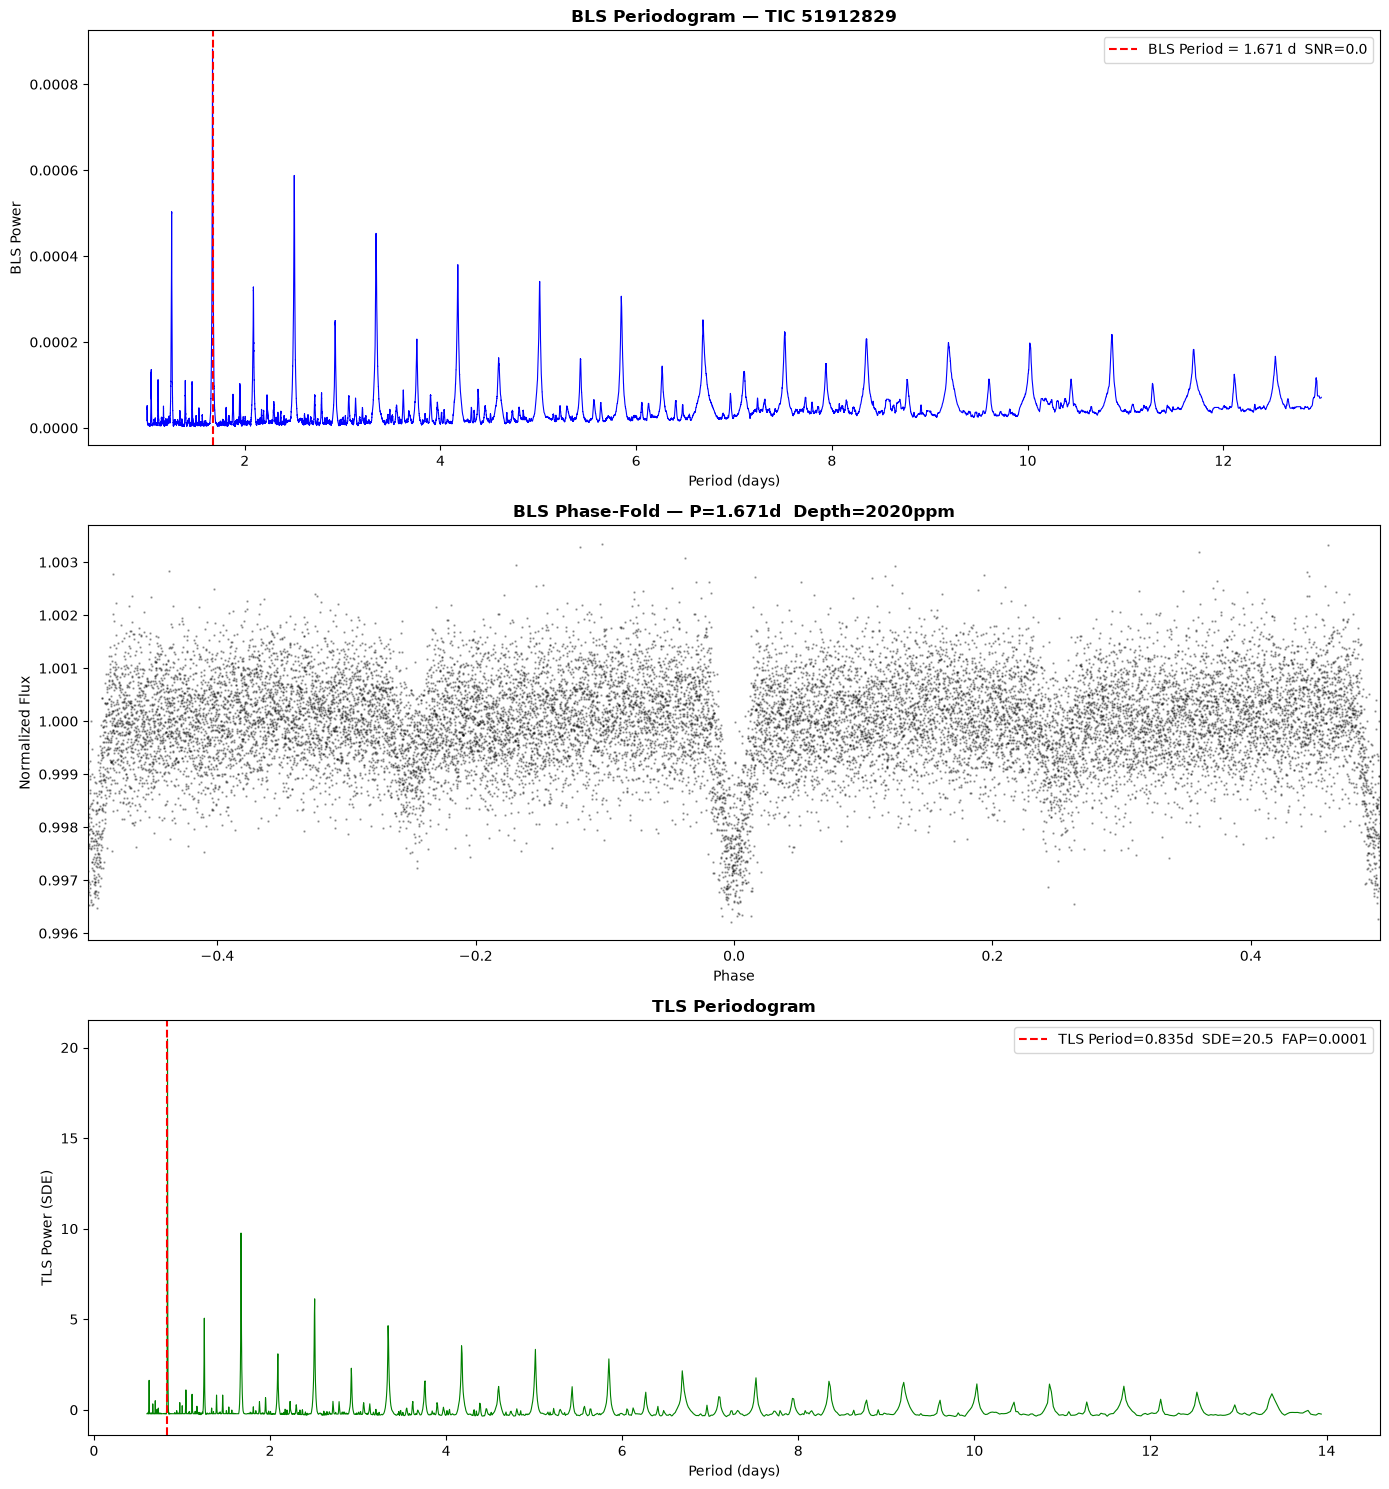

BLS vs TLS comparison plot saved!


In [17]:
# Re-run on best star to get periodogram objects
best_tic = results_df.sort_values('snr', ascending=False).iloc[0]['tic_id']
best_tic = str(best_tic).replace('.0','')
df_best  = pd.read_csv(os.path.join(PROCESSED_DIR, f'TIC_{best_tic}.csv'))
time_b   = df_best['time'].values
flux_b   = df_best['flux'].values
mask_b   = np.isfinite(time_b) & np.isfinite(flux_b)
time_b, flux_b = time_b[mask_b], flux_b[mask_b]

bls_b = run_bls(time_b, flux_b)
tls_b = run_tls(time_b, flux_b) if TLS_OK else None

n_panels = 3 if tls_b else 2
fig, axes = plt.subplots(n_panels, 1, figsize=(14, 5*n_panels))
if n_panels == 1:
    axes = [axes]

# BLS Periodogram
pgram = bls_b['periodogram']
axes[0].plot(pgram.period.value, pgram.power, 'b-', lw=0.8)
axes[0].axvline(bls_b['best_period'], color='red', linestyle='--',
                label=f"BLS Period = {bls_b['best_period']:.3f} d  SNR={bls_b['snr']:.1f}")
axes[0].set_xlabel('Period (days)')
axes[0].set_ylabel('BLS Power')
axes[0].set_title(f'BLS Periodogram — TIC {best_tic}', fontweight='bold')
axes[0].legend()

# Phase fold BLS
period_b = bls_b['best_period']
t0_b     = bls_b['transit_time']
phase_b  = ((time_b - t0_b) % period_b) / period_b
phase_b[phase_b > 0.5] -= 1.0
sidx     = np.argsort(phase_b)
axes[1].plot(phase_b[sidx], flux_b[sidx], 'k.', markersize=1.5, alpha=0.3)
axes[1].set_xlim(-0.5, 0.5)
axes[1].set_xlabel('Phase')
axes[1].set_ylabel('Normalized Flux')
axes[1].set_title(
    f'BLS Phase-Fold — P={period_b:.3f}d  Depth={bls_b["best_depth"]*1e6:.0f}ppm',
    fontweight='bold'
)

# TLS result
if tls_b and n_panels == 3:
    r = tls_b['result_obj']
    axes[2].plot(r.periods, r.power, 'g-', lw=0.8)
    axes[2].axvline(tls_b['best_period'], color='red', linestyle='--',
                    label=f"TLS Period={tls_b['best_period']:.3f}d  "
                          f"SDE={tls_b['sde']:.1f}  FAP={tls_b['fap']:.4f}")
    axes[2].set_xlabel('Period (days)')
    axes[2].set_ylabel('TLS Power (SDE)')
    axes[2].set_title('TLS Periodogram', fontweight='bold')
    axes[2].legend()

plt.tight_layout()
plots_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs', 'plots'))
os.makedirs(plots_dir, exist_ok=True)
plt.savefig(os.path.join(plots_dir, 'bls_tls_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('BLS vs TLS comparison plot saved!')

---
## ✅ Done!
**What changed vs old notebook 03:**
- Added TLS alongside BLS
- TLS gives FAP, SDE, rp_rs, odd_even_mismatch directly
- Results use TLS values as primary when available
- Both algorithms must agree on period for highest confidence

**Next → 04_feature_extraction.ipynb**